
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       0.95      0.95      0.95        21
           2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54

Kernel: linear
Accuracy: 0.9629629629629629
Precision: 0.9639376218323586
Recall: 0.9629629629629629
ROC AUC: 0.998075998075998


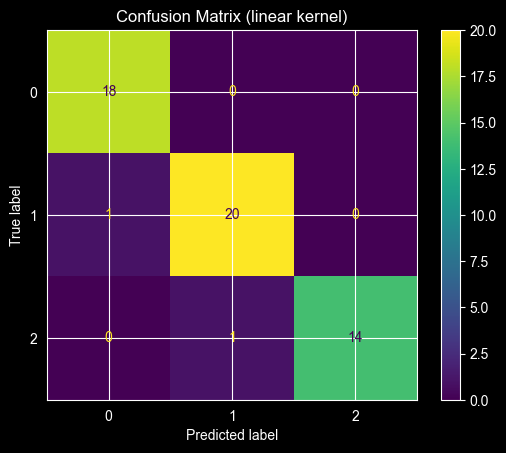


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Kernel: rbf
Accuracy: 0.9814814814814815
Precision: 0.9823232323232324
Recall: 0.9814814814814815
ROC AUC: 1.0


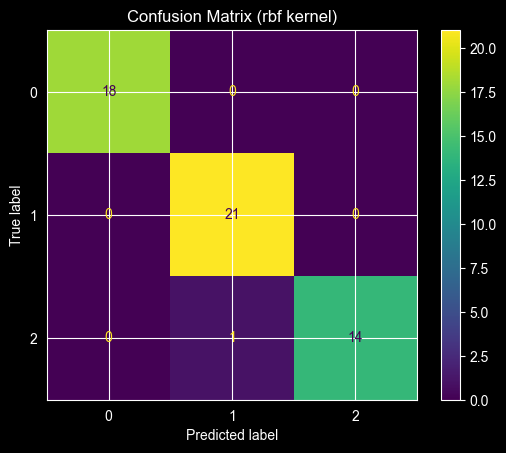


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.81      1.00      0.89        21
           2       1.00      0.87      0.93        15

    accuracy                           0.91        54
   macro avg       0.94      0.90      0.91        54
weighted avg       0.93      0.91      0.91        54

Kernel: poly
Accuracy: 0.9074074074074074
Precision: 0.9252136752136754
Recall: 0.9074074074074074
ROC AUC: 1.0


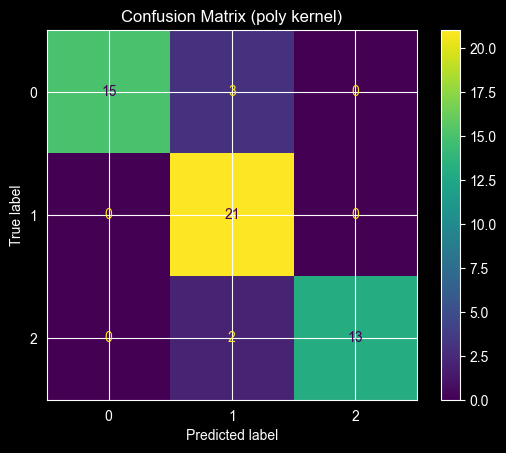


Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.90      0.95        21
           2       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54

Kernel: sigmoid
Accuracy: 0.9629629629629629
Precision: 0.9650950292397661
Recall: 0.9629629629629629
ROC AUC: 1.0


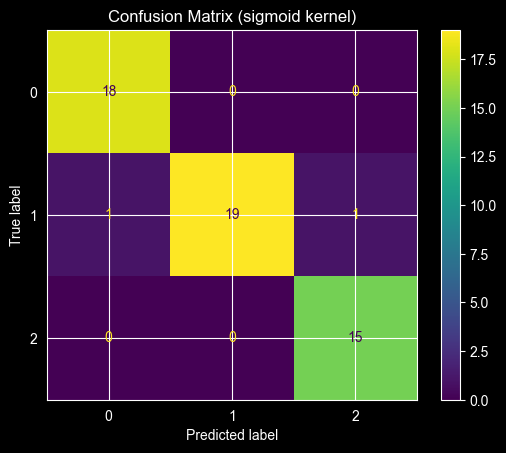


Kernel Performance Comparison
         Accuracy  Precision    Recall   ROC AUC
linear   0.962963   0.963938  0.962963  0.998076
rbf      0.981481   0.982323  0.981481  1.000000
poly     0.907407   0.925214  0.907407  1.000000
sigmoid  0.962963   0.965095  0.962963  1.000000

Best Kernel: rbf


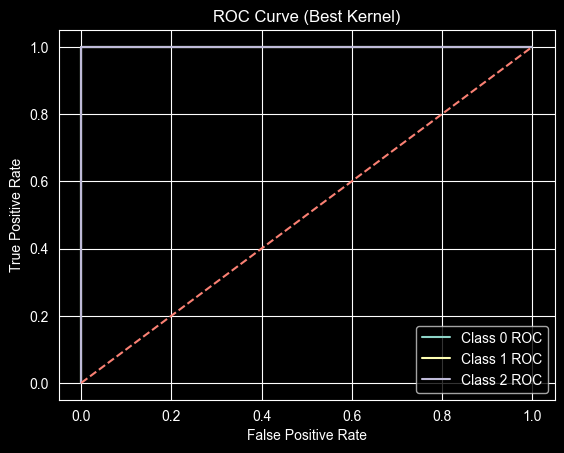

In [18]:
from more_itertools import tabulate
# Nikolas Reuter
# 1659144
# Big Data Analytics
# HW 7: SVM Classification


# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

# Load Dataset

wine = load_wine(as_frame=True)

df = wine.frame

# Drop empty data

X = df.drop(columns='target')
y = df['target']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Classification

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

results = {}

for kernel in kernels:

    svm = SVC(kernel=kernel, probability=True)

    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print("Kernel:", kernel)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)

    # ROC AUC
    y_prob = svm.predict_proba(X_test)

    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

    print("ROC AUC:", roc_auc)

    # Store results
    results[kernel] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "ROC AUC": roc_auc
    }

    # Confusion Matrices

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()

    plt.title(f"Confusion Matrix ({kernel} kernel)")
    plt.show()


# Kernel Performance Table

results_df = pd.DataFrame(results).T

print("\nKernel Performance Comparison")
print(results_df)

# ROC Curve for Best Kernel

best_kernel = results_df["Accuracy"].idxmax()

print("\nBest Kernel:", best_kernel)

model = SVC(kernel=best_kernel, probability=True)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure()

for i in range(3):

    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

    plt.plot(fpr, tpr, label=f"Class {i} ROC")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Kernel)")
plt.legend()

plt.show()